# W5Act1 — 04 Modelling

**Stage:** Modelling (when justified) → Visualisation

**This notebook is optional, and skipping it is a legitimate result.** Plenty of good
analyses stop at description. Answer DECISION 8 before running anything below it.

> **This notebook is a stage template, not a mandatory step.** Use the notebooks your
> question needs and delete the rest — a descriptive project may never open
> `04_modeling.ipynb`, and a messy dataset may spend most of its life in `01`.
> See `CHECKLIST.md` for the full workflow.

In [1]:
import sys, pathlib

ROOT = pathlib.Path.cwd()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.visualization.theme import PALETTE, save_fig, set_plot_style
set_plot_style()

# The cleaned, deduplicated frame written by 02_eda.ipynb to data/processed/.
DATASET = 'iris_clean.csv'

## DECISION 8 — Is a model justified at all?

A model earns its place by answering something description could not.

- **What the model would tell you that `02`/`03` did not:** Whether an iris's species can
  actually be *predicted* from its measurements. Description can show that petal
  measurements visually separate the three species; only a fitted, validated classifier
  says whether that separation is strong enough to assign a species to a new,
  unlabelled flower.
- **Who uses the prediction, and for what:** This is a coursework exercise (MSE803) — the
  SVM demonstrates a correctly-built multivariate classification pipeline. "Good enough"
  is held-out accuracy meaningfully above the majority-class baseline (~33%, classes are
  close to balanced).
- **Is n large enough to fit and validate?** Yes — n=147 across 3 classes (48 setosa, 50
  versicolor, 49 virginica) with 4 features is ample to both fit an SVM and hold out a
  stratified test set.
- **Decision:** model — fit an SVM classifier (already decided upstream of this
  notebook; not revisited here).

If the answer is *do not model*, write that here and stop. Delete this notebook and go to
`reports/`. That is a finished analysis, not an incomplete one.

In [2]:
from src.paths import PROCESSED

# Load the processed frame directly — 02_eda.ipynb already snake_cased the
# columns and dropped the 3 exact duplicates found in 01, so no further
# tidying is needed here.
df = pd.read_csv(PROCESSED / DATASET)
print(f'{len(df)} rows loaded from data/processed/{DATASET}')
df.head()

147 rows loaded from data/processed/iris_clean.csv


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


saved outputs/figures/04_scatter_by_species.png


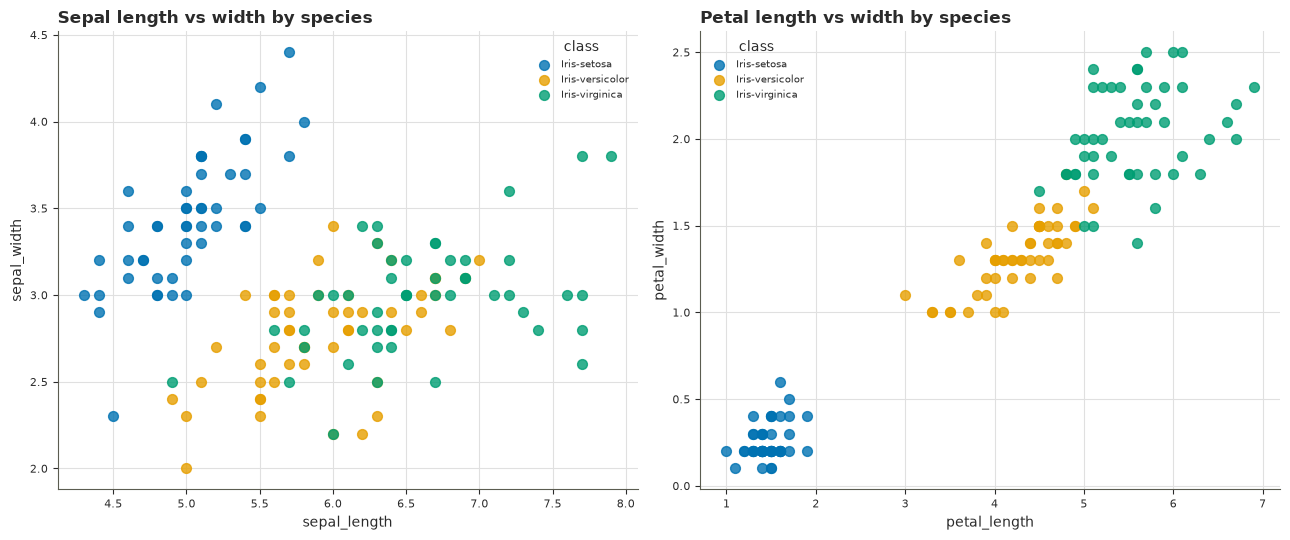

In [3]:
from src.visualization.plots import scatter_by_group

# The full 147-row processed frame, not just the training split -- the split
# happens later, once DECISION 9 below fixes predictors and target. Sepal and
# petal panels are shown side by side deliberately, not just the flattering
# petal pair: 01's DECISION 3 reading already noted petal measurements
# separate species far more cleanly than sepal width. Showing both lets that
# gap be seen directly rather than only being told about it.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
scatter_by_group(df, 'sepal_length', 'sepal_width', 'class', ax=axes[0],
                  title='Sepal length vs width by species')
scatter_by_group(df, 'petal_length', 'petal_width', 'class', ax=axes[1],
                  title='Petal length vs width by species')
fig.tight_layout()
save_fig(fig, '04_scatter_by_species')
plt.show()

### Reading

The two panels are on the same 147 rows, coloured the same way, so the difference between
them is the point. In the **sepal** panel (left), all three species overlap heavily —
setosa's sepal-width range (2.3–4.4 cm) mostly contains versicolor's (2.0–3.4 cm) and
virginica's (2.2–3.8 cm), and sepal length overlaps across all three from about 4.9–5.8 cm.
No line drawn on sepal measurements alone would cleanly separate the species.

In the **petal** panel (right), setosa sits in its own corner with no overlap at all —
petal length 1.0–1.9 cm and petal width 0.1–0.6 cm, against 3.0 cm+ and 1.0 cm+ for the
other two species. Versicolor and virginica overlap each other only in a narrow band
(petal length ~4.5–5.1 cm, petal width ~1.4–1.8 cm). This is the gap 01's DECISION 3
reading described in words — petal measurements separate species far more cleanly than
sepal width — visible directly here rather than asserted. It also previews where a
classifier's mistakes, if it makes any, are most likely to land: between versicolor and
virginica, not involving setosa.

## DECISION 9 — Predictors and target

- **Target:** `class` — the iris species (Iris-setosa / Iris-versicolor /
  Iris-virginica). This is the outcome DECISION 1 asks to predict.
- **Predictors:** all four measurement columns — `sepal_length`, `sepal_width`,
  `petal_length`, `petal_width`. Each is a physical measurement of the flower itself and
  available at prediction time (you measure a flower, then classify it) — none is
  derived from or a consequence of the species label.
- **Leakage check:** none of the four predictors are computed from `class`, and `class`
  is not derived from any of them — they are independently measured attributes of the
  same specimen. No leakage.

A ranked correlation list from `02` is not an answer to this cell. Availability and
causal ordering decide it.

In [4]:
from sklearn.model_selection import train_test_split

# Split ratio and seed as explicit, visible constants — not buried in the call.
# 80/20 is a reasonable default at n=147: it leaves ~117 rows to fit the SVM on
# and holds out ~30 to evaluate it on, split stratified by class so each
# species keeps its share in both sets. random_state fixes the split so the
# result is reproducible.
TEST_SIZE = 0.20
RANDOM_STATE = 42

TARGET_COL = 'class'
FEATURE_COLS = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'train: {X_train.shape[0]} rows x {X_train.shape[1]} features')
print(f'test:  {X_test.shape[0]} rows x {X_test.shape[1]} features')

print('\nper-class n, train:')
print(y_train.value_counts())

print('\nper-class n, test:')
print(y_test.value_counts())

train: 117 rows x 4 features
test:  30 rows x 4 features

per-class n, train:
class
Iris-versicolor    40
Iris-virginica     39
Iris-setosa        38
Name: count, dtype: int64

per-class n, test:
class
Iris-versicolor    10
Iris-virginica     10
Iris-setosa        10
Name: count, dtype: int64


### Reading

The stratified split gives 117 training rows (38 setosa, 40 versicolor, 39 virginica) and
30 test rows (10 setosa, 10 versicolor, 10 virginica) — each species keeps its original
share (roughly a third) in both sets, and the test set lands exactly balanced. No model
has been fit yet: this is the split only. SVM fitting and accuracy against the
majority-class baseline are the next, separate step.

In [5]:
from src.models.classification import compare_kernels

# Three kernels compared side by side -- which one to prefer is DECISION 10
# below, not a choice made in this cell. RBF and polynomial kernels are
# scale-sensitive (they operate on distances/dot-products between features),
# so every kernel here -- including linear -- is fit inside
# Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel=...))]), so
# scaling isn't a variable that differs between rows of the table.
# Cross-validation runs the whole pipeline per fold via
# cross_val_score(pipeline, X_train, y_train, cv=...), refitting the scaler
# on each fold's training portion only: scaling once on the full training set
# before CV would leak each held-out fold's rows into the scaler's fit.
KERNELS = ('linear', 'poly', 'rbf')
POLY_DEGREE = 3   # sklearn's own SVC default, made explicit rather than left implicit
CV_FOLDS = 5

comparison = compare_kernels(
    X_train, y_train, X_test, y_test,
    kernels=KERNELS, cv_folds=CV_FOLDS, random_state=RANDOM_STATE, poly_degree=POLY_DEGREE,
)

majority-class baseline (n = 30): 0.3333 (always predicting 'Iris-versicolor')
------------------------------------------------------------------------
kernel                test acc   cv mean    cv std        gain
------------------------------------------------------------------------
linear                  1.0000    0.9659    0.0417     +0.6667
poly (degree=3)         0.9000    0.9141    0.0281     +0.5667
rbf                     0.9667    0.9659    0.0417     +0.6333
------------------------------------------------------------------------

This function does not choose. Record the kernel and your reason in DECISION 10.


### Reading

The majority-class baseline is unchanged at 33.33% (n = 30, always predicting
Iris-versicolor). All three kernels clear it by a wide margin: linear +66.67 points
(100.00% test accuracy), rbf +63.33 points (96.67%), poly (degree=3) +56.67 points
(90.00%) — the separation the petal scatter plot showed earlier survives scaling for
every kernel, not just one.

Scaling changed linear's numbers, just not the one that was visible before. **Test
accuracy on the held-out split is unchanged at 100% (30/30)** — identical to the old
unscaled result. But the **5-fold CV mean dropped from 99.17% (std 1.67%) unscaled to
96.59% (std 4.17%) scaled**, on the *same* fold membership: `StratifiedKFold` depends only
on `y_train` and `RANDOM_STATE`, not on `X`, so the same 117 rows land in the same 5 folds
either way. Scaling shifted the linear decision boundary enough to flip one extra
misclassification in two of the folds that were previously perfect (fold std widened from
1.67 to 4.17 points). That is a real, measurable effect of adding the scaler — not an
artefact of a different split.

rbf's CV mean (96.59%, std 4.17%) matches linear's exactly, fold score for fold score —
but the two disagree on the single held-out test split: linear gets all 30 test rows
right, rbf misses one (a versicolor row placed in virginica; see the confusion matrix
below). poly (degree=3) trails both kernels on every measure here: lowest test accuracy
(90.00%) and lowest CV mean (91.41%, std 2.81%), with errors concentrated in one direction
rather than scattered (see below).

None of this points to a single kernel on its own — linear's clean test score and rbf's
identical CV mean pull in different directions, and the one-row gap between them at n = 30
is small relative to the CV std either kernel already shows. That comparison, and what to
make of it, is what DECISION 10 below is for.

saved outputs/figures/04_confusion_matrix_by_kernel.png


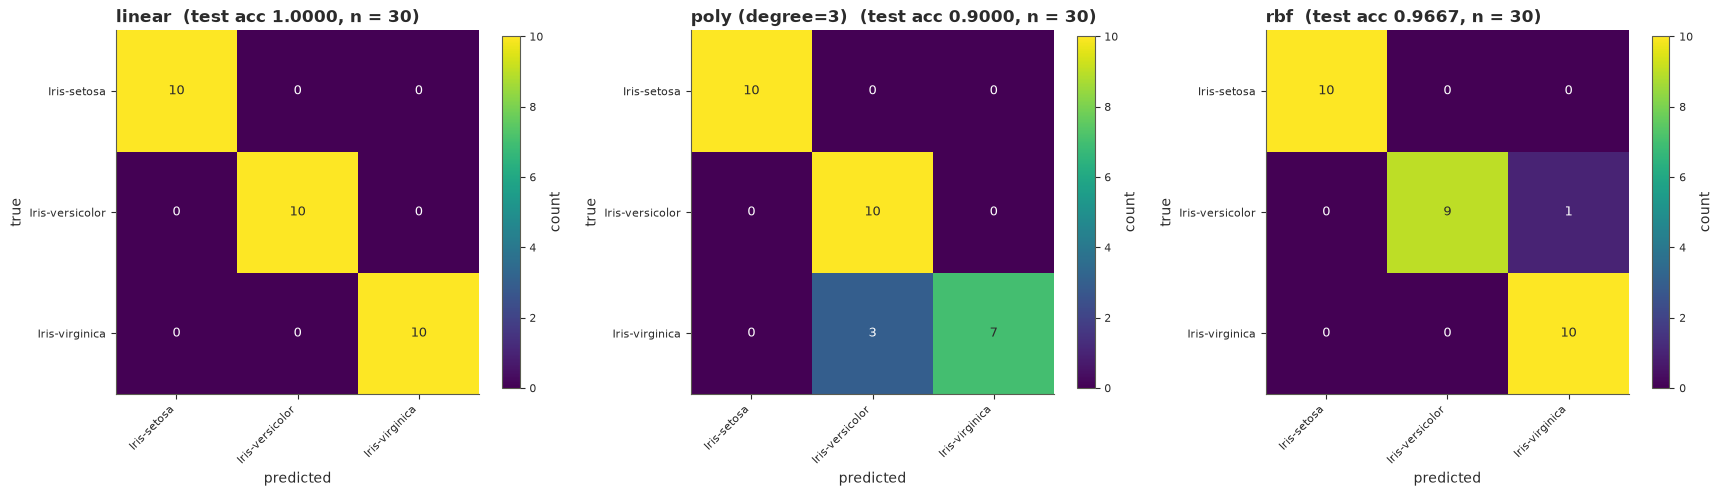

In [6]:
from sklearn.metrics import confusion_matrix

from src.visualization.plots import confusion_matrix_heatmap

labels = sorted(y.unique())
n_kernels = len(comparison['results'])
fig, axes = plt.subplots(1, n_kernels, figsize=(5.8 * n_kernels, 5.2))

for ax, r in zip(axes, comparison['results']):
    # Reuses the pipeline/y_pred compare_kernels already fit on the full
    # training set -- refitting each kernel a second time here would only
    # repeat work compare_kernels already did.
    cm = confusion_matrix(y_test, r['y_pred'], labels=labels)
    confusion_matrix_heatmap(
        cm, labels, ax=ax,
        title=f"{r['label']}  (test acc {r['test_accuracy']:.4f}, n = {len(y_test)})",
    )

fig.tight_layout()
save_fig(fig, '04_confusion_matrix_by_kernel')
plt.show()

### Reading

All three panels share the same 30 test rows (10 per species) and the same axis labels,
so the difference between them is only where each kernel's mistakes land. **linear** is
diagonal — zero errors of any kind. **rbf** makes one: a versicolor flower placed in
virginica (versicolor recall 0.90, virginica precision 0.91) — the exact overlap zone the
petal scatter plot flagged in the first figure of this notebook. **poly (degree=3)** makes
three, all in the same direction — three virginica flowers placed in versicolor (virginica
recall 0.70, versicolor precision 0.77) — a lopsided error pattern rather than mistakes
spread evenly across the boundary. Setosa is separated perfectly by every kernel in every
panel; every visible error, for every kernel, involves the versicolor/virginica pair —
consistent with the one region of overlap the earlier scatter plot showed directly, not a
new failure mode any kernel introduces.

In [7]:
from sklearn.metrics import classification_report

# Per-class precision/recall/f1 plus macro and weighted averages, per kernel --
# a single averaged accuracy scalar per kernel would hide which species (if
# any) each one confuses, and this is a 3-class problem where that matters.
for r in comparison['results']:
    print(f"=== {r['label']} ===")
    print(classification_report(y_test, r['y_pred'], labels=labels))

=== linear ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

=== poly (degree=3) ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.77      1.00      0.87        10
 Iris-virginica       1.00      0.70      0.82        10

       accuracy                           0.90        30
      macro avg       0.92      0.90      0.90        30
   weighted avg       0.92      0.90      0.90        30

=== rbf ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00    

### Reading

The per-class numbers make the confusion-matrix picture precise. **linear**: precision,
recall and f1 are 1.00 for all three species, matching its diagonal confusion matrix
exactly. **rbf**: versicolor recall drops to 0.90 and virginica precision drops to 0.91 —
its one misclassified row lowers both — while every other figure stays at 1.00; macro and
weighted averages sit at 0.97. **poly (degree=3)**: versicolor precision falls to 0.77 (it
absorbs the three misclassified virginica rows) and virginica recall falls to 0.70; macro
and weighted averages sit at 0.90/0.92 — a wider spread between its best and worst
per-class score than either linear or rbf shows. Setosa is 1.00/1.00/1.00 for every
kernel without exception. No kernel favours one class as an artefact of a scoring rule;
every asymmetry traces to the same explainable overlap — versicolor and virginica in
petal measurements — rather than a modelling quirk specific to one kernel.

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

# The classification_report above already contains this (plus the per-class
# breakdown, which is more informative) -- these three lines add nothing new
# numerically. They exist because the instructor's reference implementation
# (Week5-SVM-sample-code.py) prints precision/recall/f1 as standalone
# weighted scalars, and matching that output shape makes this notebook
# directly comparable to it, kernel by kernel.
for r in comparison['results']:
    p = precision_score(y_test, r['y_pred'], labels=labels, average='weighted')
    rec = recall_score(y_test, r['y_pred'], labels=labels, average='weighted')
    f1 = f1_score(y_test, r['y_pred'], labels=labels, average='weighted')
    print(f"{r['label']:<20} precision={p:.4f}  recall={rec:.4f}  f1={f1:.4f}")

linear               precision=1.0000  recall=1.0000  f1=1.0000
poly (degree=3)      precision=0.9231  recall=0.9000  f1=0.8977
rbf                  precision=0.9697  recall=0.9667  f1=0.9666


In [9]:
# Same flower the instructor's reference code predicts (Week5-SVM-sample-code.py,
# step 14): sepal_length=5.1, sepal_width=3.5, petal_length=1.4, petal_width=0.2.
# Using the identical vector keeps this comparable to that example. A DataFrame
# with the training feature names is used rather than a bare list, so each
# pipeline's StandardScaler sees the same column names it was fit on.
NEW_FLOWER = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=FEATURE_COLS)

print(f'new flower: {NEW_FLOWER.iloc[0].to_dict()}\n')
for r in comparison['results']:
    predicted = r['pipeline'].predict(NEW_FLOWER)[0]
    print(f"{r['label']:<20} predicts: {predicted}")

new flower: {'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_length': 1.4, 'petal_width': 0.2}

linear               predicts: Iris-setosa
poly (degree=3)      predicts: Iris-setosa
rbf                  predicts: Iris-setosa


### Reading

The weighted precision/recall/f1 lines above match the weighted-avg row of each kernel's
`classification_report` exactly (linear 1.00/1.00/1.00, poly 0.92/0.90/0.90, rbf
0.97/0.97/0.97) — they're the same numbers, printed to match the instructor's reference
output shape, not a second independent check.

All three kernels agree on the new flower (5.1, 3.5, 1.4, 0.2), predicting Iris-setosa —
unsurprising given every kernel separates setosa perfectly on both the test set and the
scatter plot, and this flower sits well inside setosa's petal range (1.0–1.9 cm long,
0.1–0.6 cm wide) with no ambiguity. This example doesn't discriminate between the three
kernels: a flower drawn from the versicolor/virginica overlap band, where the confusion
matrices above show the kernels actually disagreeing, would be a more informative one to
test by hand if you want to see them diverge.

saved outputs/figures/04_svm_decision_boundaries.png


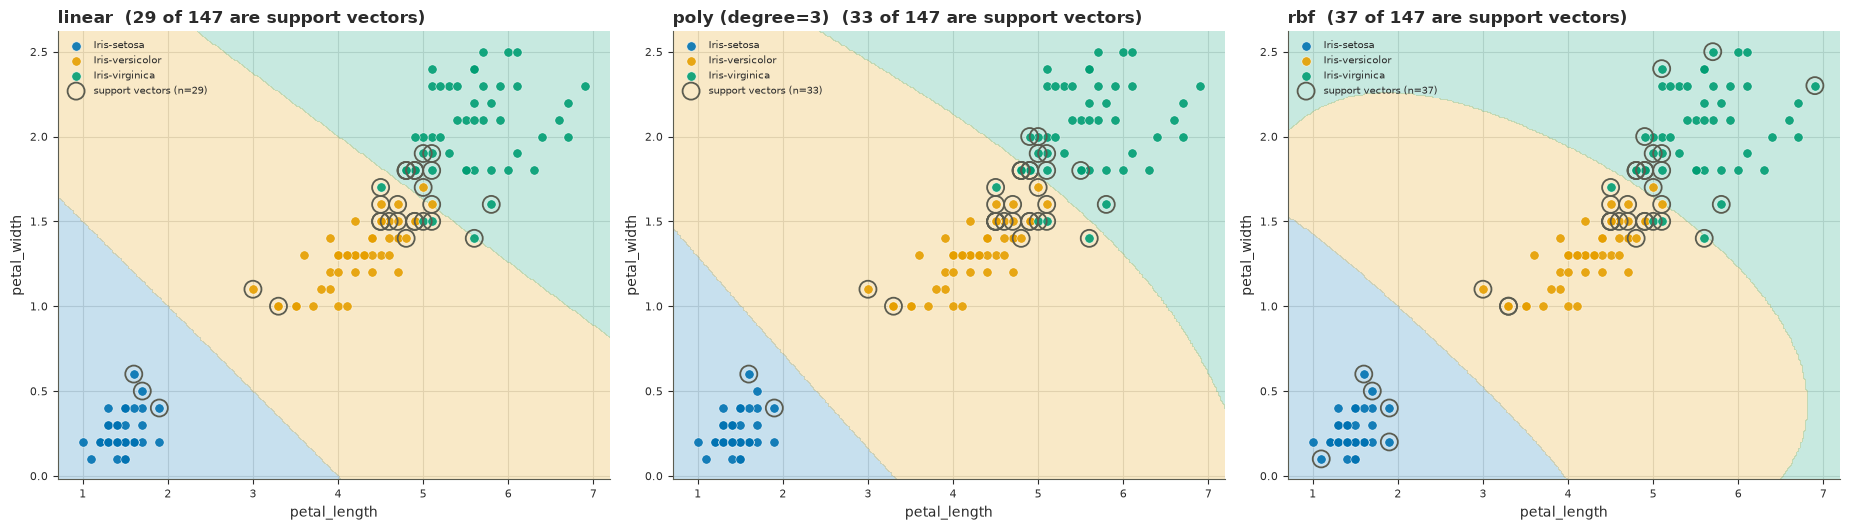

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from src.visualization.plots import svm_boundary_plot

# The mathematical formulation above describes a hyperplane in a 4-feature
# space (or higher, once a kernel maps into a larger implicit space) -- that
# can't be drawn on paper. This refits each kernel on just petal_length and
# petal_width (the pair the first scatter plot's Reading showed separates
# species most cleanly) purely to make the boundary and support vectors
# visible. This is a SEPARATE, illustrative-only model, fit on the full
# 147-row processed frame -- its shape is representative of what each kernel
# does, but its support-vector counts and boundary are not the 4-feature
# model compare_kernels evaluated above, and this cell reports no accuracy.
PLOT_FEATURES = ['petal_length', 'petal_width']
X2 = df[PLOT_FEATURES]
y2 = df[TARGET_COL]

fig, axes = plt.subplots(1, len(KERNELS), figsize=(6.2 * len(KERNELS), 5.4))
for ax, kernel in zip(axes, KERNELS):
    svm_kwargs = {'kernel': kernel}
    if kernel == 'poly':
        svm_kwargs['degree'] = POLY_DEGREE
    plot_pipeline = Pipeline([('scaler', StandardScaler()), ('svm', SVC(**svm_kwargs))])
    plot_pipeline.fit(X2, y2)

    label = f'poly (degree={POLY_DEGREE})' if kernel == 'poly' else kernel
    n_sv = plot_pipeline.named_steps['svm'].support_vectors_.shape[0]
    svm_boundary_plot(
        plot_pipeline, X2, y2, PLOT_FEATURES, ax=ax,
        title=f'{label}  ({n_sv} of {len(X2)} are support vectors)',
    )

fig.tight_layout()
save_fig(fig, '04_svm_decision_boundaries')
plt.show()

### Reading

All three panels put setosa (blue) behind a wide, dead-straight margin regardless of
kernel — its only support vectors are the 3 points nearest the boundary (petal length
1.6–1.9cm, width 0.4–0.6cm), the same three the sepal/petal scatter plot's Reading
flagged as setosa's tail end. No kernel needs to curve at all to get setosa right, which
matches every kernel scoring perfect precision/recall on it above.

The versicolor/virginica boundary (orange/green) is where the kernels visibly diverge:
**linear** draws one straight line and needs the fewest support vectors (29 of 147,
~20%). **poly (degree=3)** draws an almost-straight line too, just very slightly bowed,
with a few more support vectors (33, ~22%). **rbf** is the outlier geometrically as well
as numerically — its boundary visibly curves to wrap around individual points rather than
running straight, and it needs the most support vectors (37, ~25%) to do it. This is the
mathematical formulation made visible: a more locally-flexible kernel (rbf's `gamma`
lets each point's influence stay narrow) ends up depending on more of the training
points to define its shape, not fewer.

Every support vector circled at the versicolor/virginica boundary sits in the same petal
length 4.5–5.7cm, width 1.4–2.0cm band the confusion matrices and classification reports
already pointed to — this is the third independent way this notebook has landed on the
same region as the actual site of disagreement between species, now visible geometrically
rather than only numerically.

This is fit on the full 147-row processed frame using only 2 features, purely so the
boundary can be drawn — it does not reproduce the 4-feature train/test evaluation above,
and its support-vector counts aren't comparable to a train-only figure.

## DECISION 10 — Which model, and why

`compare_kernels` reports and stops. It returns no winner because choosing one is the
judgement you are here to make.

- **Chosen:** _<kernel>_
- **Evidence:** _<test accuracy and CV mean/std vs the baseline, for the chosen kernel --
  not training accuracy, which is not reported here for that reason>_
- **Margin:** _<is the gap over the other kernels decisive at this n, or within noise?>_
- **Rejected because:** _<for each kernel not chosen, the specific number that ruled it
  out>_

## Imputation (only if DECISION 2 permitted it)

`impute` requires `method=` and returns a provenance record. Filled values must never be
indistinguishable from observed ones downstream.

In [11]:
from src.models.imputation import METHODS, impute, write_provenance_artifacts

for name, description in METHODS.items():
    print(f'{name}:\n  {description}\n')

mean:
  Fill with the column mean. Preserves the mean, shrinks the variance and weakens every correlation. Defensible only for a few MCAR values.

median:
  Fill with the column median. As above but robust to skew and outliers.

mode:
  Fill with the most frequent value. For categoricals; inflates the majority class.

constant:
  Fill with a value you supply (pass fill_value=). Use when missing means something specific, e.g. 0 sales rather than unknown sales.

linear_regression:
  Predict from other columns with a linear fit. Needs a real relationship and complete predictors on the target rows; understates uncertainty because it imputes the conditional mean.



In [12]:
# Set from DECISION 2. No default is supplied on purpose.
IMPUTE_COL, IMPUTE_METHOD = None, None

if IMPUTE_COL and IMPUTE_METHOD:
    df_imputed, provenance = impute(
        df, IMPUTE_COL, method=IMPUTE_METHOD,
        confidence='low',        # <- your assessment, stated
    )
    display(provenance)
    write_provenance_artifacts(df, df_imputed, provenance, stem='W5Act1')
else:
    print('No imputation configured — correct if DECISION 2 said not to impute.')

No imputation configured — correct if DECISION 2 said not to impute.


## Limitations

Every model has these. Listing them is what separates a result from a claim.

- **Sample:** n=147 total (117 train / 30 test), close to balanced across three species
  (48/50/49 before splitting). This is the classic, heavily curated Iris dataset — a
  single collector, a single location and time, and four clean physical measurements
  with no missing values. It does not represent the noise, measurement error, ambiguous
  specimens or class imbalance a real-world biological survey would contain, and results
  this clean should not be expected to reproduce on messier data.
- **Validation:** One stratified 80/20 held-out test set (n=30) plus 5-fold stratified CV
  on the training set (folds of 23-24 rows), run identically for each of the three
  compared kernels. Both estimate out-of-sample accuracy, not training accuracy, which is
  the right comparison — but at n=30 a single flipped prediction moves test accuracy by
  3.3 percentage points, and at n=23-24 per CV fold, one miss moves a fold's score by
  about 4 points. Every accuracy figure in the comparison table above is a precise-looking
  number computed on very few rows; the CI around any of them is wide relative to the
  number itself, regardless of which kernel DECISION 10 settles on.
- **Assumptions:** Each kernel embeds a different assumption about the shape of the
  decision boundary between species — linear assumes the classes are (near-)separable by
  straight lines in the 4-feature space; poly and rbf allow increasingly curved
  boundaries. Which assumption fits this dataset is exactly what DECISION 10 above
  decides, and **this bullet should be revisited once that choice is recorded** — naming
  the chosen kernel's specific assumption and checking it against where that kernel's
  errors actually fall (see the confusion matrices and classification reports above, all
  of which land on the same versicolor/virginica overlap regardless of kernel). There is
  no guarantee any of these boundaries holds for flowers from a different population,
  growing region, or measurement protocol than the ones in this dataset.
- **Not causal because:** This is a pattern-recognition task, not a causal one. The four
  measurements predict species because they are a *consequence* of species (morphology
  follows taxonomy), not a cause of it — nothing here supports a claim like "increasing
  petal width would change which species a flower is." No intervention was made or could
  be; species membership was fixed before any measurement was taken.
- **Would change with:** A genuinely external test set (different specimens, different
  collection) rather than a split of the same 147 rows, which would show whether any of
  these kernels generalises beyond this particular sample; a noisier or more overlapping
  real-world dataset, which would put more test cases in the versicolor/virginica boundary
  zone and likely widen the gap between kernels rather than leave them clustered as close
  together as they are here; or hybrid/ambiguous specimens near the class boundary, which
  this dataset does not contain enough of to test.

**Next stage:** DECISION 10 above needs a human choice between the three compared
kernels before the presentation-layer decision in `CHECKLIST.md` and `reports/`.